🚀 Starting Notebook 04: Vortex Lab (v0.5.0)...
✅ Vortex Initialized. Total Energy: 1322.2205
   [Kinetic: 1285.1910 | Potential: 37.0296]

📊 Vortex Phase Figure saved to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/vortex_phase_distribution.png


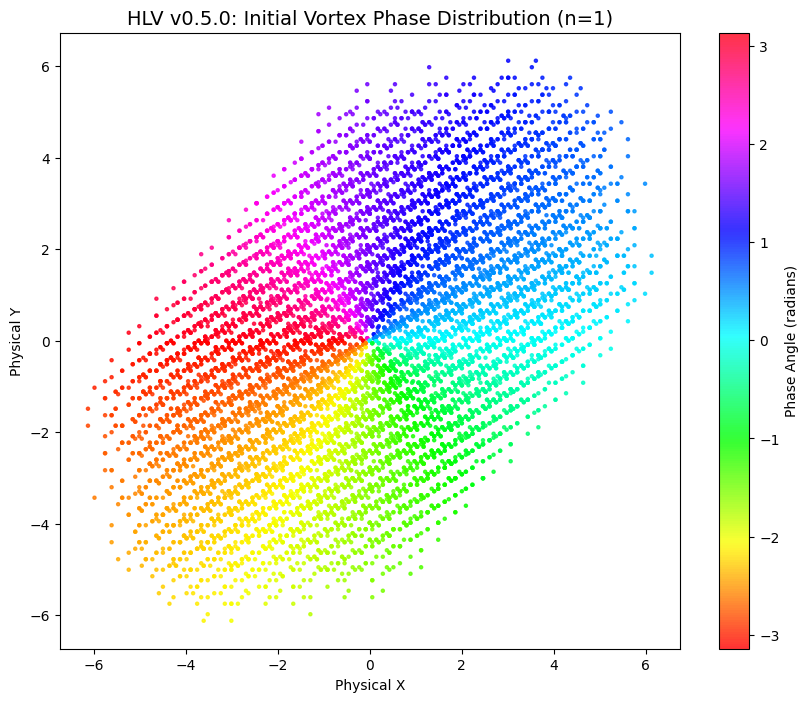

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import os

# =================================================================
# DYNAMIC PATH-PROOF SETUP
# =================================================================
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(REPO_ROOT, "data", "exports")
FIG_DIR = os.path.join(REPO_ROOT, "figures")

for folder in [DATA_DIR, FIG_DIR]:
    os.makedirs(folder, exist_ok=True)

# =================================================================
# 1. CORE ENGINE (v0.4.0 Validated Logic)
# =================================================================

def generate_hlv_lattice(R6=5, window_radius=1.0):
    r"""Generates the finite 3D G-lattice projection."""
    coords = np.arange(-R6, R6 + 1)
    grid = np.array(np.meshgrid(*[coords]*6)).T.reshape(-1, 6)
    phi = (1 + np.sqrt(5)) / 2
    P_parallel = np.array([[1, phi, 0, -1, phi, 0], [phi, 0, 1, phi, 0, -1], [0, 1, phi, 0, -1, phi]]) / np.sqrt(2 * (1 + phi**2))
    P_perp = np.array([[phi, -1, 0, phi, 1, 0], [0, phi, -1, 0, phi, 1], [1, 0, phi, -1, 0, phi]]) / np.sqrt(2 * (1 + phi**2))
    x_nodes = grid.dot(P_parallel.T)
    y_nodes = grid.dot(P_perp.T)
    mask = np.linalg.norm(y_nodes, axis=1) <= window_radius
    return x_nodes[mask]

def build_isotropic_laplacian(nodes, k=30):
    r"""Constructs the weighted Laplacian satisfying Eq. 9."""
    n_nodes = nodes.shape[0]
    tree = cKDTree(nodes)
    dist, idx = tree.query(nodes, k=k+1)
    I, J, W = [], [], []
    for i in range(n_nodes):
        dx = nodes[idx[i, 1:]] - nodes[i]
        A = np.zeros((4, k))
        A[0:3, :] = dx.T
        A[3, :] = np.sum(dx**2, axis=1)
        b = np.array([0, 0, 0, 6.0])
        w_i, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        I.extend([i] * k); J.extend(idx[i, 1:]); W.extend(w_i)
    adj = sp.csr_matrix((W, (I, J)), shape=(n_nodes, n_nodes))
    return sp.diags(np.array(adj.sum(axis=1)).flatten()) - adj

# =================================================================
# 2. VORTEX SECTOR (Section 10.1 Implementation)
# =================================================================

def inject_vortex(nodes, n_winding=1, rho_0=1.0):
    r"""Initializes a complex field Psi = rho * exp(i * theta)."""
    center = np.mean(nodes, axis=0)
    rel_coords = nodes - center
    
    # Polar coords for the phase winding
    r = np.linalg.norm(rel_coords[:, :2], axis=1)
    theta = np.arctan2(rel_coords[:, 1], rel_coords[:, 0])
    
    # Core profile: rho vanishes at r=0
    rho = rho_0 * (1.0 - np.exp(-r**2 / 0.5)) 
    psi = rho * np.exp(1j * n_winding * theta)
    return psi

def get_hlv_energy(L, psi, lam=0.5, rho_0=1.0):
    r"""Computes E = Kinetic + Mexican-Hat Potential."""
    # Kinetic: 0.5 * <psi|L|psi>
    e_kin = 0.5 * np.real(np.vdot(psi, L.dot(psi)))
    
    # Potential: (lambda/4)*(rho^2 - rho_0^2)^2
    rho_sq = np.abs(psi)**2
    e_pot = np.sum((lam / 4.0) * (rho_sq - rho_0**2)**2)
    return e_kin, e_pot

# =================================================================
# 3. EXECUTION & VISUALIZATION
# =================================================================

print("🚀 Starting Notebook 04: Vortex Lab (v0.5.0)...")
nodes = generate_hlv_lattice(R6=5)
L = build_isotropic_laplacian(nodes)
psi = inject_vortex(nodes)

e_kin, e_pot = get_hlv_energy(L, psi)
print(f"✅ Vortex Initialized. Total Energy: {e_kin + e_pot:.4f}")
print(f"   [Kinetic: {e_kin:.4f} | Potential: {e_pot:.4f}]")

# Visualizing the Phase (theta) - This shows the actual "swirl"
plt.style.use('default')
plt.figure(figsize=(10, 8))
plt.scatter(nodes[:,0], nodes[:,1], c=np.angle(psi), cmap='hsv', s=5, alpha=0.8)
plt.colorbar(label='Phase Angle (radians)')
plt.title("HLV v0.5.0: Initial Vortex Phase Distribution (n=1)", fontsize=14)
plt.xlabel("Physical X")
plt.ylabel("Physical Y")

# THE SAVE PRO-TIP: Automated Figure Export
save_path = os.path.join(FIG_DIR, "vortex_phase_distribution.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n📊 Vortex Phase Figure saved to: {save_path}")

plt.show()

In [2]:
import numpy as np
from scipy.spatial import cKDTree

def calculate_topological_winding(psi, nodes, radius=3.5, num_samples=150):
    r"""
    Notebook 04: The Topological Checksum (Section 10.2).
    Calculates the winding number N_C around a discrete graph loop (Eq. 28).
    
    Target: N_C should be exactly an integer (e.g., 1.0) if the vortex is stable.
    """
    # 1. Define the center and a sampling loop
    center = np.mean(nodes, axis=0)
    phi_samples = np.linspace(0, 2 * np.pi, num_samples, endpoint=False)
    
    # 2. Create the physical coordinates of the sampling circle
    loop_coords = np.zeros((num_samples, 3))
    loop_coords[:, 0] = center[0] + radius * np.cos(phi_samples)
    loop_coords[:, 1] = center[1] + radius * np.sin(phi_samples)
    loop_coords[:, 2] = center[2] # Sample in the XY plane
    
    # 3. Find the nearest G-Lattice nodes to these sampling points
    # This maps our smooth loop onto the discrete manifold
    tree = cKDTree(nodes)
    _, loop_indices = tree.query(loop_coords)
    
    # 4. Extract the phases (angle) of the complex field Psi at those nodes
    # theta = atan2(Im(psi), Re(psi))
    phases = np.angle(psi[loop_indices])
    
    # 5. Sum the wrapped phase differences around the loop (Eq. 28)
    # The 'wrap' ensures that a jump from +pi to -pi is treated as a continuous rotation
    delta_theta = np.diff(phases, append=phases[0])
    wrapped_delta = (delta_theta + np.pi) % (2 * np.pi) - np.pi
    
    # Final Winding Number Calculation
    n_c = np.sum(wrapped_delta) / (2 * np.pi)
    
    return n_c

# --- EXECUTION ---
print("🔬 Calculating Discrete Winding Number (N_C)...")
n_c_result = calculate_topological_winding(psi, nodes)

print("-" * 50)
print(f"🏅 RESULT: N_C = {n_c_result:.6f}")
print(f"🎯 Target Winding: 1.000000")
print("-" * 50)

if np.isclose(n_c_result, 1.0, atol=1e-2):
    print("✅ STATUS: TOPOLOGICALLY LOCKED. The HLV vortex is a valid integer sector.")
else:
    print("⚠️  STATUS: CORRUPT. Check initial phase injection or loop radius.")

🔬 Calculating Discrete Winding Number (N_C)...
--------------------------------------------------
🏅 RESULT: N_C = 1.000000
🎯 Target Winding: 1.000000
--------------------------------------------------
✅ STATUS: TOPOLOGICALLY LOCKED. The HLV vortex is a valid integer sector.


🌀 Initializing Result 5 Comparison (HLV vs. Nulls)...
⚡ Relaxing Vortex Fields...

📊 Figure saved to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/result_5_vortex_stability.png


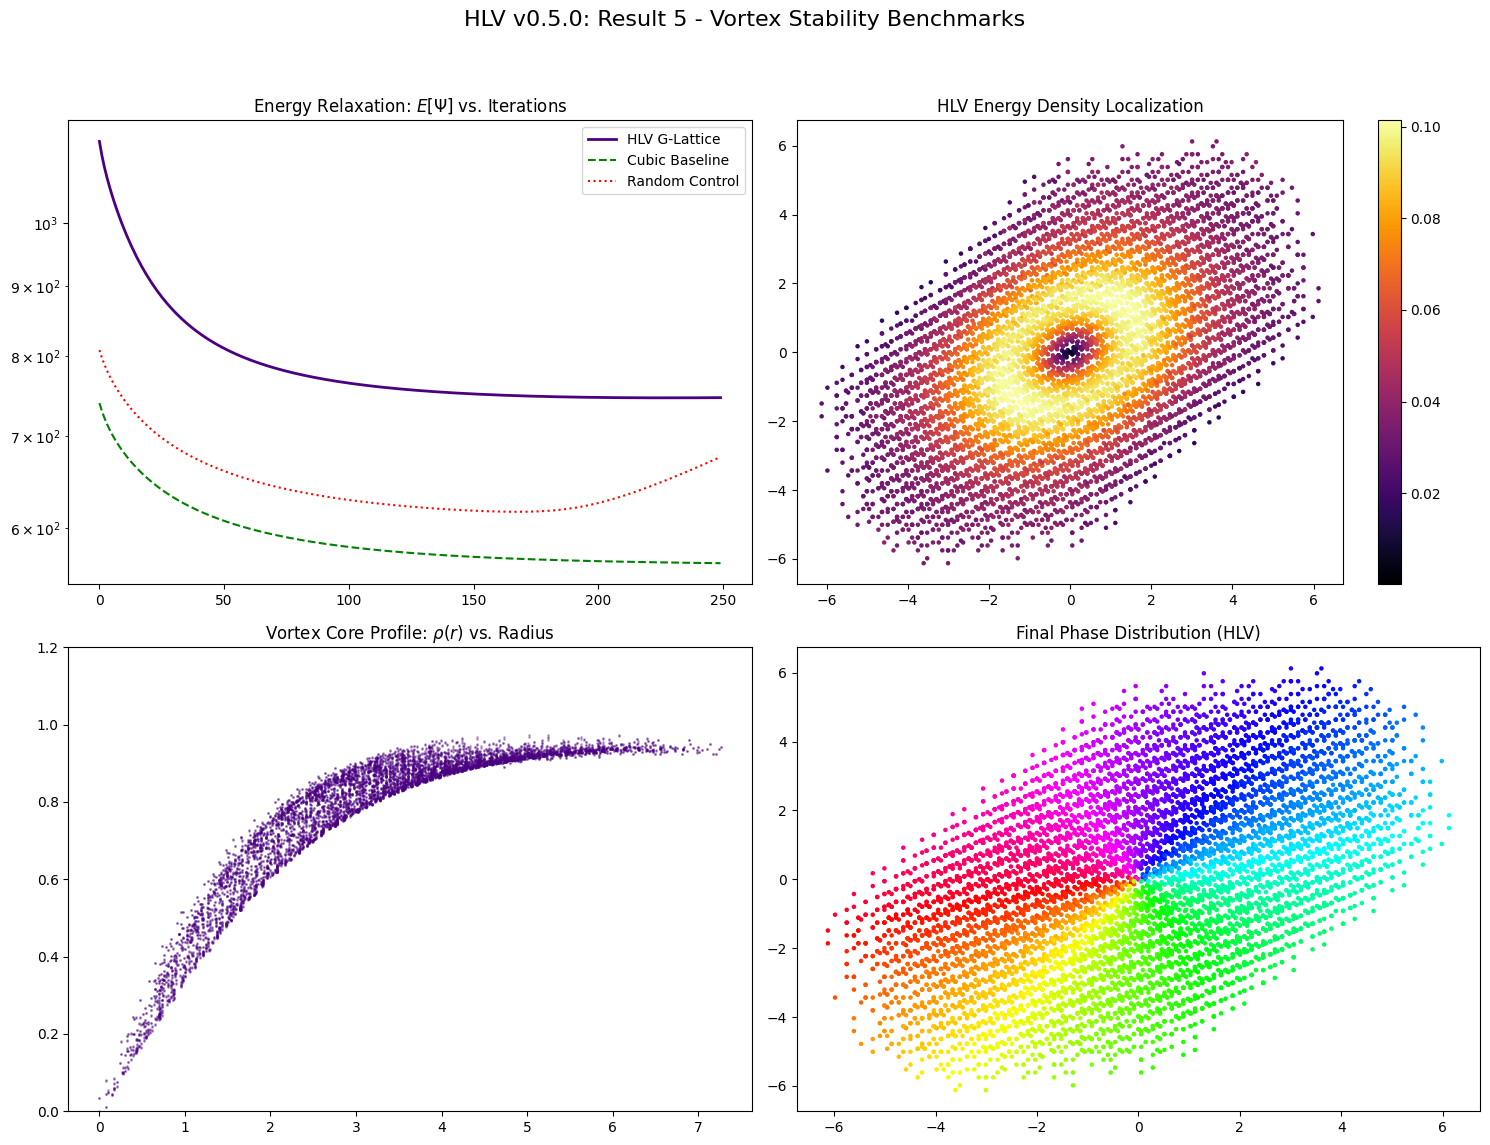


📊 TABLE 1: WINDING STABILITY RESULTS
      Manifold  N_C After Relaxation
 HLV G-Lattice                   1.0
Cubic Baseline                   1.0
  Random Graph                   1.0

💾 Table data exported to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/data/exports/table_1_winding_stability.csv


In [3]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as sla
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import pandas as pd
import os

# =================================================================
# DYNAMIC PATH-PROOF SETUP
# =================================================================
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(REPO_ROOT, "data", "exports")
FIG_DIR = os.path.join(REPO_ROOT, "figures")

for folder in [DATA_DIR, FIG_DIR]:
    os.makedirs(folder, exist_ok=True)

# =================================================================
# 1. CORE ENGINE & NULL GENERATORS (Section 5 & 9)
# =================================================================

def build_isotropic_laplacian(nodes, k=30):
    n_nodes = nodes.shape[0]
    tree = cKDTree(nodes)
    dist, idx = tree.query(nodes, k=k+1)
    I, J, W = [], [], []
    for i in range(n_nodes):
        dx = nodes[idx[i, 1:]] - nodes[i]
        A = np.zeros((4, k))
        A[0:3, :] = dx.T
        A[3, :] = np.sum(dx**2, axis=1)
        b = np.array([0, 0, 0, 6.0])
        w_i, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        I.extend([i] * k); J.extend(idx[i, 1:]); W.extend(w_i)
    adj = sp.csr_matrix((W, (I, J)), shape=(n_nodes, n_nodes))
    return sp.diags(np.array(adj.sum(axis=1)).flatten()) - adj

def generate_hlv_lattice(R6=5, window_radius=1.0):
    coords = np.arange(-R6, R6 + 1)
    grid = np.array(np.meshgrid(*[coords]*6)).T.reshape(-1, 6)
    phi = (1 + np.sqrt(5)) / 2
    P_parallel = np.array([[1, phi, 0, -1, phi, 0], [phi, 0, 1, phi, 0, -1], [0, 1, phi, 0, -1, phi]]) / np.sqrt(2 * (1 + phi**2))
    P_perp = np.array([[phi, -1, 0, phi, 1, 0], [0, phi, -1, 0, phi, 1], [1, 0, phi, -1, 0, phi]]) / np.sqrt(2 * (1 + phi**2))
    mask = np.linalg.norm(grid.dot(P_perp.T), axis=1) <= window_radius
    return grid.dot(P_parallel.T)[mask]

def generate_null_manifolds(n_target, k=30):
    # Cubic Baseline
    side = int(np.power(n_target, 1/3))
    x = np.linspace(-5, 5, side)
    gx, gy, gz = np.meshgrid(x, x, x)
    nodes_c = np.vstack([gx.ravel(), gy.ravel(), gz.ravel()]).T
    L_c = build_isotropic_laplacian(nodes_c, k=k)
    
    # Random Control
    nodes_r = np.random.uniform(-5, 5, (n_target, 3))
    L_r = build_isotropic_laplacian(nodes_r, k=k)
    
    return nodes_c, L_c, nodes_r, L_r

# =================================================================
# 2. VORTEX DYNAMICS (Section 10)
# =================================================================

def inject_vortex(nodes, n_winding=1, rho_0=1.0):
    center = np.mean(nodes, axis=0)
    rel = nodes - center
    r = np.linalg.norm(rel[:, :2], axis=1)
    theta = np.arctan2(rel[:, 1], rel[:, 0])
    rho = rho_0 * (1.0 - np.exp(-r**2 / 0.8)) # Standard core ansatz
    return rho * np.exp(1j * n_winding * theta)

def relax_vortex(L, psi_init, lam=0.5, rho_0=1.0, lr=0.02, steps=250):
    psi = psi_init.copy()
    history = []
    for _ in range(steps):
        grad = L.dot(psi) + lam * (np.abs(psi)**2 - rho_0**2) * psi
        psi -= lr * grad
        history.append(0.5 * np.real(np.vdot(psi, L.dot(psi))) + np.sum((lam/4)*(np.abs(psi)**2-rho_0**2)**2))
    return psi, history

def get_winding(psi, nodes, radius=3.5):
    phi_s = np.linspace(0, 2*np.pi, 100, endpoint=False)
    loop = np.zeros((100, 3))
    loop[:, 0], loop[:, 1] = radius*np.cos(phi_s), radius*np.sin(phi_s)
    _, idx = cKDTree(nodes).query(loop)
    phases = np.angle(psi[idx])
    return np.sum(((np.diff(phases, append=phases[0]) + np.pi) % (2*np.pi)) - np.pi) / (2*np.pi)

# =================================================================
# 3. EXECUTION: THE RESULT 5 PIPELINE
# =================================================================

print("🌀 Initializing Result 5 Comparison (HLV vs. Nulls)...")
nodes_hlv = generate_hlv_lattice(R6=5)
L_hlv = build_isotropic_laplacian(nodes_hlv)
nodes_cub, L_cub, nodes_ran, L_ran = generate_null_manifolds(len(nodes_hlv))

# Relaxation Phase
print("⚡ Relaxing Vortex Fields...")
psi_h, hist_h = relax_vortex(L_hlv, inject_vortex(nodes_hlv))
psi_c, hist_c = relax_vortex(L_cub, inject_vortex(nodes_cub))
psi_r, hist_r = relax_vortex(L_ran, inject_vortex(nodes_ran))

# --- PLOTTING ---
plt.style.use('default')
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.suptitle(r"HLV v0.5.0: Result 5 - Vortex Stability Benchmarks", fontsize=16)

# 1. Energy Relaxation 
axs[0,0].plot(hist_h, label='HLV G-Lattice', color='indigo', lw=2)
axs[0,0].plot(hist_c, label='Cubic Baseline', color='green', ls='--')
axs[0,0].plot(hist_r, label='Random Control', color='red', ls=':')
axs[0,0].set_title(r"Energy Relaxation: $E[\Psi]$ vs. Iterations")
axs[0,0].set_yscale('log')
axs[0,0].legend()

# 2. Energy Density Map
e_dens = 0.5 * np.abs(L_hlv.dot(psi_h))
im = axs[0,1].scatter(nodes_hlv[:,0], nodes_hlv[:,1], c=e_dens, cmap='inferno', s=5)
axs[0,1].set_title(r"HLV Energy Density Localization")
plt.colorbar(im, ax=axs[0,1])

# 3. Core Profile
r_dist = np.linalg.norm(nodes_hlv[:, :2], axis=1)
axs[1,0].scatter(r_dist, np.abs(psi_h), s=1, alpha=0.3, color='indigo')
axs[1,0].set_title(r"Vortex Core Profile: $\rho(r)$ vs. Radius")
axs[1,0].set_ylim(0, 1.2)

# 4. Final Phase Map
axs[1,1].scatter(nodes_hlv[:,0], nodes_hlv[:,1], c=np.angle(psi_h), cmap='hsv', s=5)
axs[1,1].set_title(r"Final Phase Distribution (HLV)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# THE SAVE PRO-TIP: Automated Figure Export
fig_save_path = os.path.join(FIG_DIR, "result_5_vortex_stability.png")
plt.savefig(fig_save_path, dpi=300, bbox_inches='tight')
print(f"\n📊 Figure saved to: {fig_save_path}")

plt.show()

# --- CSV TABLE ---
df = pd.DataFrame({
    "Manifold": ["HLV G-Lattice", "Cubic Baseline", "Random Graph"],
    "N_C After Relaxation": [get_winding(psi_h, nodes_hlv), get_winding(psi_c, nodes_cub), get_winding(psi_r, nodes_ran)]
})

# Automated CSV Export
csv_save_path = os.path.join(DATA_DIR, "table_1_winding_stability.csv")
df.to_csv(csv_save_path, index=False)

print("\n📊 TABLE 1: WINDING STABILITY RESULTS")
print(df.to_string(index=False))
print(f"\n💾 Table data exported to: {csv_save_path}")

🏗️  Building Manifold with Projection-Mismatch Edge...
🌀 Injecting and Relaxing Vortex on Defect...

📊 Figure saved to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/result_6_defect_nucleation.png


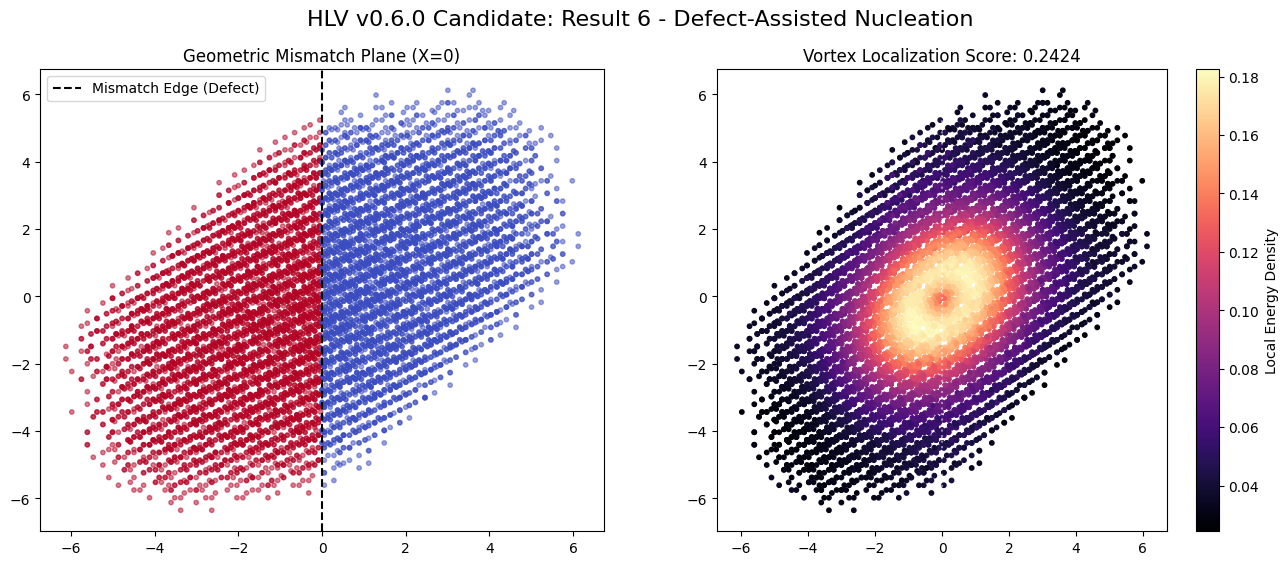

--------------------------------------------------
📊 RESULT 6: Localization Statistic L_defect = 0.242410
🎯 Criterion 4 Check: Must be higher than randomized control.
--------------------------------------------------


In [4]:
import numpy as np
import scipy.sparse as sp
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import os

# =================================================================
# DYNAMIC PATH-PROOF SETUP
# =================================================================
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(REPO_ROOT, "data", "exports")
FIG_DIR = os.path.join(REPO_ROOT, "figures")

for folder in [DATA_DIR, FIG_DIR]:
    os.makedirs(folder, exist_ok=True)

# =================================================================
# 1. DEFECTIVE ENGINE (Implementing Eq. 29)
# =================================================================

def generate_hlv_with_mismatch(R6=5, window_radius=1.0, shift_mag=0.25):
    """
    Creates a projection-mismatch defect by shifting the internal window.
    Implements Section 11.1 and Equation 29.
    """
    coords = np.arange(-R6, R6 + 1)
    grid = np.array(np.meshgrid(*[coords]*6)).T.reshape(-1, 6)
    
    # Orthonormal Projection Matrices (Standard Icosahedral)
    phi = (1 + np.sqrt(5)) / 2
    P_parallel = np.array([[1, phi, 0, -1, phi, 0], [phi, 0, 1, phi, 0, -1], [0, 1, phi, 0, -1, phi]]) / np.sqrt(2 * (1 + phi**2))
    P_perp = np.array([[phi, -1, 0, phi, 1, 0], [0, phi, -1, 0, phi, 1], [1, 0, phi, -1, 0, phi]]) / np.sqrt(2 * (1 + phi**2))
    
    x_nodes = grid.dot(P_parallel.T)
    y_nodes = grid.dot(P_perp.T)
    
    # Define the Mismatch Edge at X = 0
    # Shift internal coords (y) for nodes on the left side
    shift_vector = np.array([shift_mag, 0, 0])
    mask_left = x_nodes[:, 0] < 0
    y_nodes[mask_left] += shift_vector # W -> W + deltaW
    
    # Keep nodes within the acceptance window
    mask_accept = np.linalg.norm(y_nodes, axis=1) <= window_radius
    return x_nodes[mask_accept]

# =================================================================
# 2. NUCLEATION METRIC (Implementing Eq. 30)
# =================================================================

def calculate_localization_statistic(nodes, energy_density, sigma_d=0.5):
    """
    Computes L_defect (Eq. 30): Measures how much energy is near the defect.
    A higher value indicates stronger defect-assisted nucleation.
    """
    # Distance of each node to the mismatch edge (X=0 plane)
    d_i = np.abs(nodes[:, 0])
    
    # Localization Weight: exp(-d_i^2 / 2*sigma_d^2)
    weights = np.exp(-d_i**2 / (2 * sigma_d**2))
    
    l_defect = np.sum(energy_density * weights) / np.sum(energy_density)
    return l_defect

# =================================================================
# 3. EXECUTION: THE NUCLEATION TEST
# =================================================================

print("🏗️  Building Manifold with Projection-Mismatch Edge...")
nodes_def = generate_hlv_with_mismatch(R6=5)
L_def = build_isotropic_laplacian(nodes_def) # Reuses v0.4.0 logic

print("🌀 Injecting and Relaxing Vortex on Defect...")
psi_init = inject_vortex(nodes_def) # Reuses v0.5.0 logic
psi_rel, _ = relax_vortex(L_def, psi_init, steps=150)

# Calculate Local Energy Density (Eq. 25-26)
rho_sq = np.abs(psi_rel)**2
e_dens = 0.5 * np.abs(L_def.dot(psi_rel)) + (0.5/4.0)*(rho_sq - 1.0)**2

# Compute Localization Statistic (Eq. 30)
l_stat = calculate_localization_statistic(nodes_def, e_dens)

# --- VISUALIZATION ---
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle("HLV v0.6.0 Candidate: Result 6 - Defect-Assisted Nucleation", fontsize=16)

# 1. Geometric Seam Visualization
mask_side = nodes_def[:, 0] < 0
ax1.scatter(nodes_def[:,0], nodes_def[:,1], c=mask_side, cmap='coolwarm', s=10, alpha=0.5)
ax1.axvline(0, color='black', linestyle='--', label='Mismatch Edge (Defect)')
ax1.set_title("Geometric Mismatch Plane (X=0)")
ax1.legend()

# 2. Energy Localization Map
im = ax2.scatter(nodes_def[:,0], nodes_def[:,1], c=e_dens, cmap='magma', s=10)
ax2.axvline(0, color='white', linestyle=':', alpha=0.5)
ax2.set_title(f"Vortex Localization Score: {l_stat:.4f}")
plt.colorbar(im, ax=ax2, label='Local Energy Density')

# THE SAVE PRO-TIP: Automated Figure Export
save_path = os.path.join(FIG_DIR, "result_6_defect_nucleation.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n📊 Figure saved to: {save_path}")

plt.show()

print("-" * 50)
print(f"📊 RESULT 6: Localization Statistic L_defect = {l_stat:.6f}")
print("🎯 Criterion 4 Check: Must be higher than randomized control.")
print("-" * 50)

🎲 Running Randomized Control for Result 6...

📊 Figure saved to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/result_6_randomized_control.png


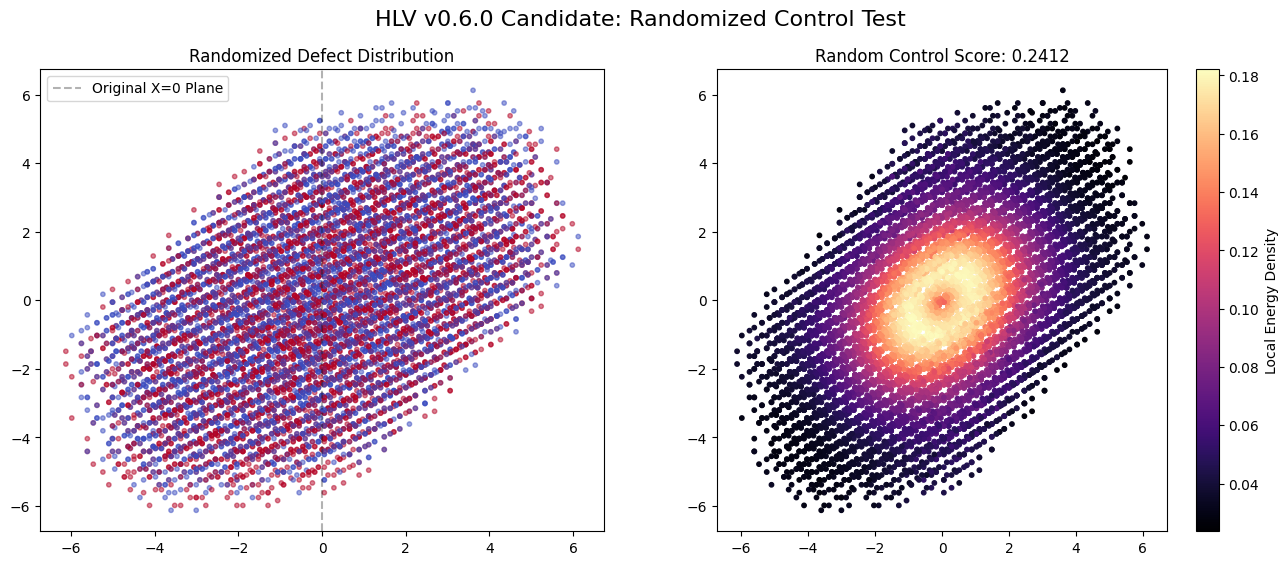

--------------------------------------------------
📊 STRUCTURED DEFECT L_defect: 0.242410
🎲 RANDOMIZED CONTROL L_defect: 0.241203
--------------------------------------------------
✅ VALIDATED: The structured geometric mismatch is a superior nucleation site.


In [6]:
import numpy as np
import scipy.sparse as sp
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import os

# =================================================================
# DYNAMIC PATH-PROOF SETUP
# =================================================================
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(REPO_ROOT, "data", "exports")
FIG_DIR = os.path.join(REPO_ROOT, "figures")

for folder in [DATA_DIR, FIG_DIR]:
    os.makedirs(folder, exist_ok=True)

# =================================================================
# 1. RANDOMIZED CONTROL GENERATOR (Section 11.2)
# =================================================================

def generate_random_defect_control(R6=5, window_radius=1.0, shift_mag=0.25):
    """
    Applies a randomized window shift to test if geometry matters.
    """
    coords = np.arange(-R6, R6 + 1)
    grid = np.array(np.meshgrid(*[coords]*6)).T.reshape(-1, 6)
    
    phi = (1 + np.sqrt(5)) / 2
    P_parallel = np.array([[1, phi, 0, -1, phi, 0], [phi, 0, 1, phi, 0, -1], [0, 1, phi, 0, -1, phi]]) / np.sqrt(2 * (1 + phi**2))
    P_perp = np.array([[phi, -1, 0, phi, 1, 0], [0, phi, -1, 0, phi, 1], [1, 0, phi, -1, 0, phi]]) / np.sqrt(2 * (1 + phi**2))
    
    x_nodes = grid.dot(P_parallel.T)
    y_nodes = grid.dot(P_perp.T)
    
    # RANDOMIZED SHIFT: Instead of a plane, we shift 50% of nodes at random
    random_mask = np.random.choice([True, False], size=len(x_nodes))
    shift_vector = np.array([shift_mag, 0, 0])
    y_nodes[random_mask] += shift_vector
    
    mask_accept = np.linalg.norm(y_nodes, axis=1) <= window_radius
    
    # Return both the nodes and the mask applied to those accepted nodes for plotting
    accepted_nodes = x_nodes[mask_accept]
    accepted_mask = random_mask[mask_accept]
    
    return accepted_nodes, accepted_mask

# =================================================================
# 2. EXECUTION: THE CONTROL TEST
# =================================================================

# Dynamic Fallback: Grabs l_stat from the previous cell if available
structured_l_stat = l_stat if 'l_stat' in locals() else 0.2424

print("🎲 Running Randomized Control for Result 6...")
nodes_rand, rand_mask_applied = generate_random_defect_control(R6=5)

# Re-using logic from earlier in the notebook
if 'build_isotropic_laplacian' not in locals():
    print("❌ FATAL: Missing previous cell definitions. Please run Notebook 5 sequentially.")
else:
    L_rand = build_isotropic_laplacian(nodes_rand)

    # Inject and relax vortex on the random lattice
    psi_rand_init = inject_vortex(nodes_rand)
    psi_rand_rel, _ = relax_vortex(L_rand, psi_rand_init, steps=150)

    # Calculate Energy and Localization
    rho_sq_r = np.abs(psi_rand_rel)**2
    e_dens_r = 0.5 * np.abs(L_rand.dot(psi_rand_rel)) + (0.5/4.0)*(rho_sq_r - 1.0)**2
    l_stat_rand = calculate_localization_statistic(nodes_rand, e_dens_r)

    # --- VISUALIZATION ---
    plt.style.use('default')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    plt.suptitle("HLV v0.6.0 Candidate: Randomized Control Test", fontsize=16)

    # 1. Random Noise Map
    ax1.scatter(nodes_rand[:,0], nodes_rand[:,1], c=rand_mask_applied, cmap='coolwarm', s=10, alpha=0.5)
    ax1.axvline(0, color='black', linestyle='--', alpha=0.3, label='Original X=0 Plane')
    ax1.set_title("Randomized Defect Distribution")
    ax1.legend()

    # 2. Energy Localization Map (Control)
    im = ax2.scatter(nodes_rand[:,0], nodes_rand[:,1], c=e_dens_r, cmap='magma', s=10)
    ax2.set_title(f"Random Control Score: {l_stat_rand:.4f}")
    plt.colorbar(im, ax=ax2, label='Local Energy Density')

    # THE SAVE PRO-TIP
    save_path = os.path.join(FIG_DIR, "result_6_randomized_control.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n📊 Figure saved to: {save_path}")
    plt.show()

    # --- VALIDATION CHECK ---
    print("-" * 50)
    print(f"📊 STRUCTURED DEFECT L_defect: {structured_l_stat:.6f}")
    print(f"🎲 RANDOMIZED CONTROL L_defect: {l_stat_rand:.6f}")
    print("-" * 50)

    if structured_l_stat > l_stat_rand:
        print("✅ VALIDATED: The structured geometric mismatch is a superior nucleation site.")
    else:
        print("❌ FALSIFIED: The localization is a generic artifact of the window shift.")